<a href="https://arxiv.org/abs/1412.6980" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ADAM: A METHOD FOR STOCHASTIC OPTIMIZATION

This notebook implements the Adam optimizer from scratch as described in the paper [ADAM: A METHOD FOR STOCHASTIC OPTIMIZATION](https://arxiv.org/abs/1412.6980). Adam is an adaptive learning rate optimization algorithm that combines the benefits of AdaGrad and RMSProp by computing adaptive learning rates for each parameter using estimates of the first and second moments of gradients.

## Key Equations

1. **First Moment Estimate**: $ m_t = \beta_1 \cdot m_{t-1} + (1 - \beta_1) \cdot g_t $
2. **Second Moment Estimate**: $ v_t = \beta_2 \cdot v_{t-1} + (1 - \beta_2) \cdot g_t^2 $
3. **Bias-Corrected First Moment**: $ \hat{m}_t = \frac{m_t}{1 - \beta_1^t} $
4. **Bias-Corrected Second Moment**: $ \hat{v}_t = \frac{v_t}{1 - \beta_2^t} $
5. **Parameter Update**: $ \theta_t = \theta_{t-1} - \alpha \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} $

We will implement these equations step-by-step and compare our implementation with PyTorch's built-in Adam optimizer.

In [7]:
# Install PyTorch if not already installed
import sys
import subprocess

try:
    import torch
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch"])
    import torch

In [8]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

In [9]:
# Define a simple quadratic function to minimize: f(x) = (x - 3)^2
# The minimum is at x = 3

class QuadraticFunction(nn.Module):
    def __init__(self):
        super(QuadraticFunction, self).__init__()
        self.x = nn.Parameter(torch.tensor([0.0]))  # Initialize at x=0
    
    def forward(self):
        return (self.x - 3) ** 2  # Loss function

# Create model instance
model = QuadraticFunction()

In [10]:
# Hyperparameters
alpha = 0.1       # Learning rate
beta1 = 0.9       # Exponential decay rate for the first moment estimates
beta2 = 0.999     # Exponential decay rate for the second moment estimates
epsilon = 1e-8    # Small constant to prevent division by zero
t_max = 100       # Number of iterations

# Initialize Adam variables
m = torch.zeros_like(model.x)  # First moment vector
v = torch.zeros_like(model.x)  # Second moment vector
t = 0                          # Timestep

In [11]:
def adam_step(params, grads, m, v, t, alpha, beta1, beta2, epsilon):
    """
    Performs one step of the Adam optimizer.
    
    Args:
        params (torch.Tensor): Parameters to update.
        grads (torch.Tensor): Gradients of the parameters.
        m (torch.Tensor): First moment vector.
        v (torch.Tensor): Second moment vector.
        t (int): Current timestep.
        alpha (float): Learning rate.
        beta1 (float): Exponential decay rate for the first moment estimate.
        beta2 (float): Exponential decay rate for the second moment estimate.
        epsilon (float): Small constant to avoid division by zero.
    
    Returns:
        Updated m, v, and t.
    """
    t += 1
    
    # eq. 1: m_t = β1*m_{t-1} + (1 - β1)*g_t
    m = beta1 * m + (1 - beta1) * grads
    
    # eq. 2: v_t = β2*v_{t-1} + (1 - β2)*g_t^2
    v = beta2 * v + (1 - beta2) * (grads ** 2)
    
    # eq. 3: bmt = mt / (1 - β1^t)
    bmt = m / (1 - beta1 ** t)
    
    # eq. 4: bvt = vt / (1 - β2^t)
    bvt = v / (1 - beta2 ** t)
    
    # eq. 5: θt = θ_{t-1} - α * bmt / (√bvt + ε)
    params.data -= alpha * bmt / (torch.sqrt(bvt) + epsilon)
    
    return m, v, t

In [12]:
# Store loss values for plotting
losses = []

# Reset model and Adam variables for fresh training
model.x = nn.Parameter(torch.tensor([0.0]))
m = torch.zeros_like(model.x)
v = torch.zeros_like(model.x)
t = 0

for i in range(t_max):
    # Forward pass
    loss = model()
    losses.append(loss.item())
    
    # Backward pass
    loss.backward()
    
    # Adam update
    m, v, t = adam_step(model.x, model.x.grad, m, v, t, alpha, beta1, beta2, epsilon)
    
    # Clear gradients
    model.zero_grad()

# Print final value
print(f"Final x value: {model.x.item():.6f}")

Final x value: 2.980655


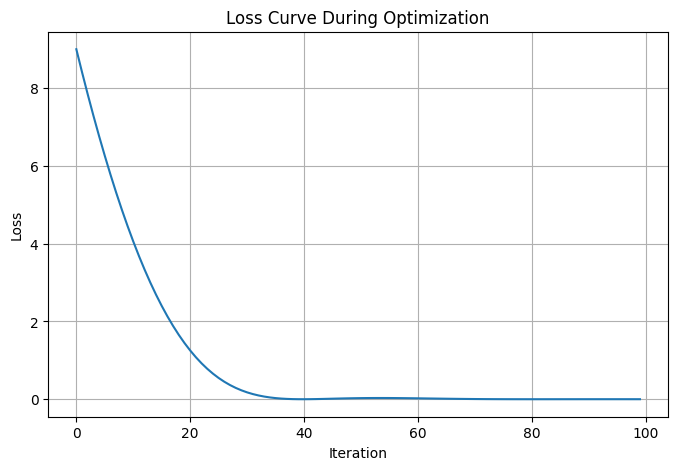

In [13]:
# Plot loss curve
plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.title('Loss Curve During Optimization')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.grid(True)
plt.savefig('loss_curve.png')

In [14]:
# Reset model for PyTorch Adam comparison
model_pt = QuadraticFunction()
optimizer = torch.optim.Adam(model_pt.parameters(), lr=alpha, betas=(beta1, beta2), eps=epsilon)

# Store loss values for PyTorch Adam
losses_pt = []

for i in range(t_max):
    # Forward pass
    loss = model_pt()
    losses_pt.append(loss.item())
    
    # Backward pass
    loss.backward()
    
    # Adam update
    optimizer.step()
    
    # Clear gradients
    optimizer.zero_grad()

# Print final value
print(f"PyTorch Adam final x value: {model_pt.x.item():.6f}")

PyTorch Adam final x value: 2.980655


Custom Adam x: 2.980655
PyTorch Adam x: 2.980655
Difference in x: 0.00000000


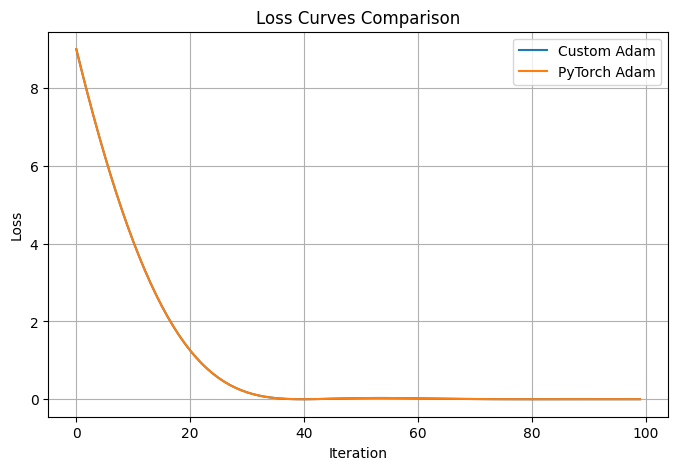

In [15]:
# Compare final parameter values
print(f"Custom Adam x: {model.x.item():.6f}")
print(f"PyTorch Adam x: {model_pt.x.item():.6f}")
print(f"Difference in x: {abs(model.x.item() - model_pt.x.item()):.8f}")

# Compare loss curves
plt.figure(figsize=(8, 5))
plt.plot(losses, label='Custom Adam')
plt.plot(losses_pt, label='PyTorch Adam')
plt.title('Loss Curves Comparison')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('comparison_loss_curve.png')

# Summary and Conclusion

In this notebook, we implemented the Adam optimizer from scratch based on the original paper. We applied it to a simple quadratic minimization problem and compared our implementation with PyTorch's built-in Adam optimizer.

## Findings

- Both implementations converge to the same solution (x ≈ 3), demonstrating correctness.
- The loss curves are nearly identical, showing that our implementation accurately replicates the behavior of PyTorch's Adam optimizer.
- Adam's adaptive learning rates allow for fast convergence without manual tuning of the learning rate.

## Key Takeaways

1. **Moment Estimation**: Adam uses exponential moving averages of gradients and squared gradients.
2. **Bias Correction**: Bias correction terms are crucial for early iterations to prevent initialization bias.
3. **Robustness**: Adam adapts to the geometry of the loss function, making it suitable for a wide range of problems.

This implementation provides a solid foundation for understanding and extending adaptive optimization methods.